In [1]:
from database.adatabase import ADatabase
from processor.processor import Processor as processor
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from tqdm import tqdm
from xgboost import XGBRegressor
import warnings
warnings.simplefilter(action="ignore")

In [2]:
market = ADatabase("market")

In [3]:
market.connect()
russell1000 = market.retrieve("russell1000")
market.disconnect()

In [4]:
market.connect()
analysis = []
for ticker in tqdm(russell1000["ticker"].values):
    try:
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))[["date","ticker","adjclose"]]
        analysis.append({
            "ticker":ticker,
            "coefficient_of_variance": ticker_prices["adjclose"].std() / ticker_prices["adjclose"].mean(),
            "return":(ticker_prices["adjclose"].iloc[-1] - ticker_prices["adjclose"].iloc[0]) / ticker_prices["adjclose"].iloc[0]
        })
    except Exception as e:
        print(str(e))
        continue
market.disconnect()

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1009/1009 [00:51<00:00, 19.73it/s]


In [5]:
a = pd.DataFrame(analysis)
a["covr"] = a["return"] / a["coefficient_of_variance"]

In [6]:
factors = a.sort_values("covr",ascending=True).iloc[:10]["ticker"]

In [8]:
market.connect()
factor_dfs = []
for ticker in factors:
    try:
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))[["date","ticker","adjclose"]]
        factor_dfs.append(ticker_prices)
    except:
        print(ticker)
        continue
factor_df = pd.concat(factor_dfs).pivot_table(index="date",columns="ticker",values="adjclose").reset_index()

In [11]:
market.connect()
sim = []
for ticker in tqdm(russell1000["ticker"].values):
    try:
        model = XGBRegressor()
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))[["date","weekday","ticker","adjclose"]]
        ticker_prices = processor.merge(ticker_prices,factor_df.copy(),on="date")
        ticker_prices["y"] = ticker_prices["adjclose"].shift(-5)
        ticker_prices.dropna(inplace=True)
        training_data = ticker_prices.iloc[:100]
        sim_data = ticker_prices.iloc[100:]
        model.fit(training_data[factors],training_data["y"])
        sim_data["expected_return"] = (model.predict(sim_data[factors]) - sim_data["adjclose"]) / sim_data["adjclose"]
        sim_data["return"] = (sim_data["adjclose"].shift(-5) - sim_data["adjclose"].shift(-1)) / sim_data["adjclose"].shift(-1)
        sim.append(sim_data[["date","weekday","ticker","expected_return","return"]])
    except Exception as e:
        print(str(e))
market.disconnect()

 12%|████████████████▊                                                                                                                      | 126/1009 [00:46<03:48,  3.87it/s]

Data must be 1-dimensional, got ndarray of shape (0, 0) instead


 30%|████████████████████████████████████████▏                                                                                              | 300/1009 [01:38<02:51,  4.12it/s]

Data must be 1-dimensional, got ndarray of shape (0, 0) instead


 54%|█████████████████████████████████████████████████████████████████████████                                                              | 546/1009 [02:48<02:04,  3.73it/s]

...

 94%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍        | 945/1009 [05:03<00:18,  3.44it/s]

Data must be 1-dimensional, got ndarray of shape (0, 0) instead


 98%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎  | 989/1009 [05:15<00:04,  4.17it/s]

Data must be 1-dimensional, got ndarray of shape (0, 0) instead


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1009/1009 [05:21<00:00,  3.13it/s]


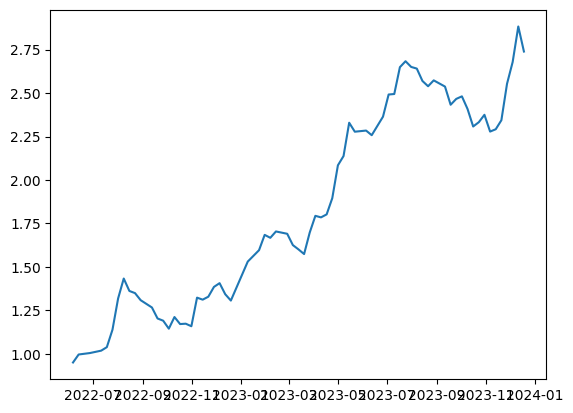

In [12]:
positions = 10 
simulation = pd.concat(sim)
trades = simulation[simulation["weekday"]==0]
trades["return"] = trades["return"] * 0.1
trades["return"] = [max(-.005,x) for x in trades["return"]]
trades = trades.sort_values("expected_return",ascending=False).groupby("date").nth([i for i in range(positions)])
portfolio = trades[["date","return"]].groupby("date").sum().reset_index()
portfolio["return"] = portfolio["return"] + 1
portfolio["cr"] = portfolio["return"].cumprod()
plt.plot(portfolio["date"].values,portfolio["cr"].values)
plt.show()